# 02b — Event Response in NQ and ZN: Is CPI Also the Valuable Release There?

## Purpose

Notebooks 01–02 established, **for ES**, that CPI is the only macro release whose surprise strongly and reliably moves the market: headline CPI at −18 to −24 bps per 1-SD surprise, R² 22–30%, against weak NFP and PCE effects. Notebooks 05–07 then applied the surprise strategy to NQ and ZN **without repeating that analysis for them**.

This notebook repeats the **Notebook 02 event study for NQ (Nasdaq-100) and ZN (10-year T-note)**, with ES as the reference, to answer:

> **Is CPI also the only valuable release for NQ and ZN, or do other releases matter there?**

**Two measurements for every market, release and horizon:**
1. **Reaction** (Notebook 02 definition): $R_{T,h} = \ln(P_{T+h-1}/P_{T-1})$, which includes the first-minute jump. It shows **how much the release moves the market**.
2. **Tradeable drift** (Notebook 04 definition): $D_{T,h} = \ln(P_{T+h-1}/P_{T})$, starting after the first post-release bar. It shows **whether a trader can still profit** from the surprise.

**Same data and specification as Notebook 02:** the 363 releases in `macro_event_model_data_2016_2026.parquet` (CPI, NFP, PCE, 2016–2026), the same z-scored surprise components, and multivariate regressions with robust (HC3) standard errors.

**Reading ZN:** ZN is a **bond price**. When yields rise, ZN falls. A hot inflation print or a strong jobs print should therefore **lower** ZN, while strong jobs data **raises** ES and NQ.

## 1. Setup

In [1]:
from pathlib import Path
import sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
EVENT_FILE = PROCESSED_DIR / "macro_event_model_data_2016_2026.parquet"     # Notebook 02 output
MARKETS = {
    "ES": (RAW_DIR / "ES_1m_2010_2026_full.parquet", "project"),
    "NQ": (TEAM_DATA / "futures_1min_clean_v3_NQ.parquet", "team_v3"),
    "ZN": (TEAM_DATA / "futures_1min_clean_v3_ZN.parquet", "team_v3"),
}

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.multi_asset as ma
for m in (sc, ma):
    importlib.reload(m)

print("Event file:", EVENT_FILE.exists())
for s, (f, _) in MARKETS.items():
    print(f"{s}: {f.exists()}")

HORIZONS = [1, 5, 15, 30, 60]
DRIFT_HORIZONS = [5, 15, 30, 60]
FAMILY_VARS = {                       # the Notebook 02 regression specification
    "CPI": ["headline_cpi", "core_cpi"],
    "NFP": ["nonfarm_payrolls", "unemployment_rate", "avg_hourly_earnings"],
    "PCE": ["headline_pce", "core_pce"],
}
SPLIT = "2021-01-01"                  # stability check: 2016-2020 vs 2021-2026

Event file: True
ES: True
NQ: True
ZN: True


## 2. Load the Notebook 02 Event Dataset

In [2]:
ev = pd.read_parquet(EVENT_FILE)
ev["timestamp_utc"] = pd.to_datetime(ev["timestamp_utc"], utc=True)
ev = ev.sort_values("timestamp_utc").reset_index(drop=True)
print("Events:", len(ev), "|", ev["timestamp_utc"].min().date(), "to", ev["timestamp_utc"].max().date())
display(ev["event_type"].value_counts().to_frame("n"))

Events: 363 | 2016-01-08 to 2026-06-25


,n
event_type,
NFP,122
CPI,122
PCE,119


## 3. Returns for ES, NQ and ZN at Every Release

Prices are the close of each 1-minute bar (bars labelled by their start minute, as in Notebook 02), roll-adjusted within each market. For release time $T$:
- reaction over $h$ minutes: close of bar $T+h-1$ vs close of bar $T-1$
- drift over $h$ minutes: close of bar $T+h-1$ vs close of bar $T$ (entry about 1 minute after the release)

In [3]:
def returns_at(adj, ts):
    idx = adj.index.as_unit("ns") if hasattr(adj.index, "as_unit") else adj.index
    t_ns = idx.asi8
    lp = adj["logp_adj"].to_numpy()
    T = pd.DatetimeIndex(ts)
    T = T.as_unit("ns") if hasattr(T, "as_unit") else T
    def at(label):
        x = T.asi8 + label * 60 * 10**9
        pos = np.searchsorted(t_ns, x, side="right") - 1
        ok = (pos >= 0) & ((x - t_ns[np.clip(pos, 0, None)]) <= 5 * 60 * 10**9)
        return np.where(ok, lp[np.clip(pos, 0, None)], np.nan)
    pre, p0 = at(-1), at(0)
    out = pd.DataFrame(index=T)
    for h in HORIZONS:
        out[f"ret_{h}m"] = (at(h - 1) - pre) * 1e4
    for h in DRIFT_HORIZONS:
        out[f"drift_{h}m"] = (at(h - 1) - p0) * 1e4
    return out

R = {}
for sym, (path, kind) in MARKETS.items():
    adj = ma.adjusted(ma.load_bars(path, kind))
    R[sym] = returns_at(adj, ev["timestamp_utc"])
    print(f"{sym}: releases with a complete 60-minute reaction: {R[sym]['ret_60m'].notna().sum()} / {len(ev)}")

# validation: ES must reproduce the Notebook 02 returns
gaps = {h: float(np.nanmax(np.abs(R['ES'][f'ret_{h}m'].to_numpy() - ev[f'ret_{h}m_bps'].to_numpy()))) for h in HORIZONS}
print("\nMax |ES here - Notebook 02| by horizon (bps):", {h: f"{g:.1e}" for h, g in gaps.items()})
print("(small differences can only come from contract rolls inside a window; Notebook 02 used unadjusted prices)")

ES: releases with a complete 60-minute reaction: 363 / 363
NQ: releases with a complete 60-minute reaction: 354 / 363
ZN: releases with a complete 60-minute reaction: 350 / 363

Max |ES here - Notebook 02| by horizon (bps): {1: '3.4e-11', 5: '3.4e-11', 15: '3.5e-11', 30: '3.4e-11', 60: '3.4e-11'}
(small differences can only come from contract rolls inside a window; Notebook 02 used unadjusted prices)


## 4. Market Impact: How Much Does Each Release Move Each Market?

In [4]:
rows = []
for sym in MARKETS:
    d = pd.concat([ev[["event_type"]], R[sym].reset_index(drop=True)], axis=1)
    for fam_, g in d.groupby("event_type"):
        rows.append({"market": sym, "release": fam_, **{f"|{h}m|": g[f"ret_{h}m"].abs().mean() for h in HORIZONS}})
impact = pd.DataFrame(rows).set_index(["market", "release"])
impact.to_csv(RESULTS_DIR / "nb02b_market_impact.csv")
print("Mean absolute reaction (bps) by market and release:")
display(impact.round(1))

# relative impact: each release vs the market's average release (removes the fact that ZN moves less than ES)
rel = impact["|30m|"].unstack("release")
rel = rel.div(rel.mean(axis=1), axis=0)
print("\nRelative 30-minute impact (1.00 = the market's average across CPI, NFP, PCE):")
display(rel.round(2))

Mean absolute reaction (bps) by market and release:


|1m|   |5m|  |15m|  |30m|  |60m|
market release                                   
ES     CPI     28.100 31.400 34.600 38.500 37.800
       NFP     21.500 26.300 26.100 29.600 29.200
       PCE      7.000  9.400 12.900 14.900 18.100
NQ     CPI     38.600 44.700 48.400 53.600 54.000
       NFP     25.600 31.600 31.500 36.000 35.100
       PCE      9.200 12.500 17.200 18.500 23.200
ZN     CPI     18.400 20.200 21.400 22.500 24.000
       NFP     20.000 21.600 22.200 23.600 24.400
       PCE      4.900  6.100  7.300  8.300  9.300


Relative 30-minute impact (1.00 = the market's average across CPI, NFP, PCE):


release,CPI,NFP,PCE
market,,,
ES,1.390,1.070,0.540
NQ,1.490,1.000,0.510
ZN,1.240,1.300,0.460


## 5. Reaction Regressions (Notebook 02 Specification)

For each market, release and horizon: $R_{T,h} = \alpha + \sum_k \beta_k\, z_k + \varepsilon$ with the release's surprise components, and HC3 robust standard errors. $\beta$ is in **bps per 1-SD surprise**.

In [5]:
def regress(y, X):
    d = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(d) < 20:
        return None
    r = sc.ols_hc3(d["y"], pd.concat([pd.Series(1.0, index=d.index, name="const"), d[X.columns]], axis=1))
    return r

def run_regs(kind, horizons, sample=None):
    rows = []
    for sym in MARKETS:
        d = pd.concat([ev, R[sym].reset_index(drop=True)], axis=1)
        if sample is not None:
            d = d[sample(d)]
        for fam_, vars_ in FAMILY_VARS.items():
            g = d[d["event_type"] == fam_]
            for h in horizons:
                r = regress(g[f"{kind}_{h}m"], g[vars_])
                if r is None:
                    continue
                for v in vars_:
                    rows.append(dict(market=sym, release=fam_, horizon=h, variable=v, n=r.n,
                                     beta=r.params[v], t=r.t[v], p=r.p[v], r2=r.r2))
    return pd.DataFrame(rows)

react = run_regs("ret", HORIZONS)
react.to_csv(RESULTS_DIR / "nb02b_reaction_regressions.csv", index=False)

r2 = react.drop_duplicates(["market", "release", "horizon"]).pivot_table(index=["release", "horizon"], columns="market", values="r2")
print("R² of the reaction regression (share of the move explained by the surprise):")
display(r2[list(MARKETS)].round(3))

R² of the reaction regression (share of the move explained by the surprise):


market             ES    NQ    ZN
release horizon                  
CPI     1       0.299 0.323 0.337
        5       0.273 0.296 0.297
        15      0.223 0.261 0.265
        30      0.252 0.290 0.255
        60      0.231 0.271 0.251
NFP     1       0.028 0.012 0.020
        5       0.034 0.013 0.027
        15      0.050 0.006 0.030
        30      0.041 0.003 0.014
        60      0.070 0.011 0.014
PCE     1       0.138 0.169 0.104
        5       0.096 0.102 0.041
        15      0.058 0.052 0.017
        30      0.026 0.034 0.016
        60      0.032 0.039 0.018

In [6]:
key_vars = ["headline_cpi", "core_cpi", "nonfarm_payrolls", "unemployment_rate", "avg_hourly_earnings", "headline_pce", "core_pce"]
for h in [5, 30]:
    t = react[react.horizon == h].pivot_table(index="variable", columns="market", values=["beta", "t"]).reindex(key_vars)
    t.columns = [f"{m} {s}" for s, m in t.columns]
    print(f"\nReaction over {h} minutes: beta (bps per 1-SD surprise) and t-stat")
    display(t[[f"{m} {s}" for m in MARKETS for s in ["beta", "t"]]].round(2))


Reaction over 5 minutes: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,ZN beta,ZN t
variable,,,,,,
headline_cpi,-20.760,-2.830,-27.740,-2.720,-9.920,-2.770
core_cpi,-6.410,-1.080,-9.710,-1.180,-4.580,-1.540
nonfarm_payrolls,2.770,1.050,2.480,0.980,-1.550,-0.850
unemployment_rate,4.260,1.150,4.820,1.340,-1.750,-0.720
avg_hourly_earnings,-0.970,-0.060,-0.900,-0.050,-0.190,-0.030
headline_pce,-3.820,-1.780,-5.210,-1.990,-0.900,-0.950
core_pce,-0.780,-0.450,-1.010,-0.430,-0.730,-0.870



Reaction over 30 minutes: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,ZN beta,ZN t
variable,,,,,,
headline_cpi,-23.770,-2.650,-30.480,-2.550,-10.580,-2.760
core_cpi,-7.080,-0.910,-12.810,-1.250,-4.470,-1.380
nonfarm_payrolls,2.530,0.980,1.260,0.430,-1.400,-0.910
unemployment_rate,2.650,0.640,2.290,0.520,-2.110,-0.870
avg_hourly_earnings,-0.730,-0.060,-0.490,-0.040,-0.540,-0.080
headline_pce,-3.260,-1.460,-4.200,-1.370,-0.790,-0.580
core_pce,-0.690,-0.240,-1.380,-0.360,-0.620,-0.640


**How to read it.** Compare the **R²** and the **t-stats** across markets. If CPI is the dominant release in every market, its R² should be clearly higher than NFP's and PCE's in NQ and ZN too. For ZN, expect **negative** betas on inflation and on strong jobs data (bond prices fall when yields rise).

## 6. Tradeable Drift Regressions (after the first minute)

In [7]:
drift = run_regs("drift", DRIFT_HORIZONS)
drift.to_csv(RESULTS_DIR / "nb02b_drift_regressions.csv", index=False)
d30 = drift[drift.horizon == 30].pivot_table(index="variable", columns="market", values=["beta", "t"]).reindex(key_vars)
d30.columns = [f"{m} {s}" for s, m in d30.columns]
print("Tradeable drift T+1 -> T+30: beta (bps per 1-SD surprise) and t-stat")
display(d30[[f"{m} {s}" for m in MARKETS for s in ["beta", "t"]]].round(2))

r2d = drift.drop_duplicates(["market", "release", "horizon"]).pivot_table(index=["release", "horizon"], columns="market", values="r2")
print("\nR² of the drift regression:")
display(r2d[list(MARKETS)].round(3))

Tradeable drift T+1 -> T+30: beta (bps per 1-SD surprise) and t-stat


,ES beta,ES t,NQ beta,NQ t,ZN beta,ZN t
variable,,,,,,
headline_cpi,-5.670,-1.370,-4.590,-0.900,-0.060,-0.040
core_cpi,-0.290,-0.090,-4.150,-0.920,-0.820,-0.670
nonfarm_payrolls,0.180,0.090,-0.580,-0.400,0.130,0.100
unemployment_rate,-1.040,-0.380,-0.530,-0.190,0.010,0.000
avg_hourly_earnings,-1.000,-0.340,-0.660,-0.250,-0.420,-0.360
headline_pce,0.430,0.220,1.270,0.470,0.450,0.470
core_pce,0.150,0.070,0.040,0.010,0.360,0.560



R² of the drift regression:


market             ES    NQ    ZN
release horizon                  
CPI     5       0.018 0.016 0.006
        15      0.013 0.021 0.003
        30      0.053 0.068 0.005
        60      0.039 0.053 0.013
NFP     5       0.072 0.058 0.016
        15      0.040 0.015 0.013
        30      0.034 0.008 0.007
        60      0.061 0.020 0.009
PCE     5       0.000 0.003 0.012
        15      0.004 0.004 0.012
        30      0.001 0.003 0.008
        60      0.001 0.001 0.011

### 6.1 Is the drift stable across periods? (2016–2020 vs 2021–2026)

In [8]:
early = run_regs("drift", [30], sample=lambda d: d["timestamp_utc"] < pd.Timestamp(SPLIT, tz="UTC"))
late = run_regs("drift", [30], sample=lambda d: d["timestamp_utc"] >= pd.Timestamp(SPLIT, tz="UTC"))
k = ["market", "release", "variable"]
stab = (early[k + ["n", "beta", "t"]].merge(late[k + ["n", "beta", "t"]], on=k, suffixes=("_2016_20", "_2021_26")))
stab["same_sign"] = np.sign(stab["beta_2016_20"]) == np.sign(stab["beta_2021_26"])
stab.to_csv(RESULTS_DIR / "nb02b_drift_stability.csv", index=False)
display(stab.set_index(k).round(2))

n_2016_20  beta_2016_20  t_2016_20  n_2021_26  beta_2021_26  t_2021_26  same_sign
market release variable                                                                                              
ES     CPI     headline_cpi                58        -4.730     -1.740         64        -7.420     -0.910       True
               core_cpi                    58        -1.590     -0.520         64         1.660      0.220      False
       NFP     nonfarm_payrolls            60         0.470      0.260         61        -2.440     -0.120      False
               unemployment_rate           60        -0.390     -0.140         61        -8.660     -0.730       True
               avg_hourly_earnings         60        -1.080     -0.490         61         4.480      0.430      False
       PCE     headline_pce                56        -0.690     -0.290         63         1.830      0.540      False
               core_pce                    56         1.840      0.840         63        -1.970     -0.500      False
NQ     CPI     headline_cpi                51        -5.340     -1.680         64        -4.430     -0.440       True
               core_cpi                    51        -4.750     -1.210         64        -3.740     -0.380       True
       NFP     nonfarm_payrolls            60        -0.270     -0.200         60       -17.550     -0.520       True
               unemployment_rate           60         0.120      0.040         60        -3.870     -0.230      False
               avg_hourly_earnings         60        -0.790     -2.520         60         8.060      0.600      False
       PCE     headline_pce                56         0.750      0.260         62         1.830      0.340       True
               core_pce                    56         0.740      0.270         62        -1.130     -0.200      False
ZN     CPI     headline_cpi                58         0.550      0.410         64         0.220      0.060       True
               core_cpi                    58         0.230      0.240         64        -1.860     -0.700      False
       NFP     nonfarm_payrolls            59         0.490      0.460         61         6.360      0.380       True
               unemployment_rate           59         0.820      0.500         61       -13.480     -1.470      False
               avg_hourly_earnings         59        -0.410     -0.420         61        -1.030     -0.140       True
       PCE     headline_pce                46        -0.110     -0.130         61         0.940      0.560      False
               core_pce                    46         0.350      0.490         61         0.300      0.290       True

## 7. Summary: Which Release Is Valuable in Each Market?

A release is marked **valuable for trading** in a market if its main surprise variable has a tradeable-drift t-stat above 2 in absolute value (T+1 → T+30), **and** the same sign in 2016–2020 and 2021–2026. The main variables are headline CPI, nonfarm payrolls and headline PCE, as in Notebook 02.

In [9]:
MAIN = {"CPI": "headline_cpi", "NFP": "nonfarm_payrolls", "PCE": "headline_pce"}
rows = []
for sym in MARKETS:
    for fam_, v in MAIN.items():
        rr = react[(react.market == sym) & (react.release == fam_) & (react.variable == v) & (react.horizon == 5)]
        dd = drift[(drift.market == sym) & (drift.release == fam_) & (drift.variable == v) & (drift.horizon == 30)]
        ss = stab[(stab.market == sym) & (stab.release == fam_) & (stab.variable == v)]
        if rr.empty or dd.empty:
            continue
        rows.append(dict(market=sym, release=fam_, variable=v,
                         impact_30m_bps=impact.loc[(sym, fam_), "|30m|"],
                         reaction_beta_5m=rr.beta.iat[0], reaction_t_5m=rr.t.iat[0], reaction_r2_5m=rr.r2.iat[0],
                         drift_beta_30m=dd.beta.iat[0], drift_t_30m=dd.t.iat[0],
                         drift_same_sign_both_periods=bool(ss.same_sign.iat[0]) if not ss.empty else np.nan))
summary = pd.DataFrame(rows)
summary["moves_market"] = summary["reaction_t_5m"].abs() > 2
summary["valuable_for_trading"] = (summary["drift_t_30m"].abs() > 2) & (summary["drift_same_sign_both_periods"] == True)
summary = summary.set_index(["market", "release"])
summary.to_csv(RESULTS_DIR / "nb02b_summary.csv")
display(summary.round(3))

print("\nVALUABLE FOR TRADING (drift |t| > 2 and stable sign):")
for (sym, fam_), r in summary.iterrows():
    flag = "YES" if r.valuable_for_trading else "no"
    print(f"  {sym} {fam_:<4s} reaction t {r.reaction_t_5m:+6.2f} (R² {r.reaction_r2_5m:.2f}) | "
          f"drift t {r.drift_t_30m:+6.2f} | stable sign: {r.drift_same_sign_both_periods} -> {flag}")

variable  impact_30m_bps  reaction_beta_5m  reaction_t_5m  reaction_r2_5m  drift_beta_30m  drift_t_30m  drift_same_sign_both_periods  moves_market  valuable_for_trading
market release                                                                                                                                                                                  
ES     CPI          headline_cpi          38.462           -20.758         -2.829           0.273          -5.665       -1.373                          True          True                 False
       NFP      nonfarm_payrolls          29.565             2.771          1.049           0.034           0.176        0.094                         False         False                 False
       PCE          headline_pce          14.888            -3.824         -1.779           0.096           0.428        0.221                         False         False                 False
NQ     CPI          headline_cpi          53.581           -27.742         -2.717           0.296          -4.588       -0.896                          True          True                 False
       NFP      nonfarm_payrolls          35.979             2.478          0.983           0.013          -0.582       -0.397                          True         False                 False
       PCE          headline_pce          18.519            -5.215         -1.986           0.102           1.268        0.466                          True         False                 False
ZN     CPI          headline_cpi          22.470            -9.921         -2.774           0.297          -0.059       -0.035                          True          True                 False
       NFP      nonfarm_payrolls          23.623            -1.545         -0.845           0.027           0.128        0.103                          True         False                 False
       PCE          headline_pce           8.269            -0.904         -0.952           0.041           0.455        0.469                         False         False                 False


VALUABLE FOR TRADING (drift |t| > 2 and stable sign):
  ES CPI  reaction t  -2.83 (R² 0.27) | drift t  -1.37 | stable sign: True -> no
  ES NFP  reaction t  +1.05 (R² 0.03) | drift t  +0.09 | stable sign: False -> no
  ES PCE  reaction t  -1.78 (R² 0.10) | drift t  +0.22 | stable sign: False -> no
  NQ CPI  reaction t  -2.72 (R² 0.30) | drift t  -0.90 | stable sign: True -> no
  NQ NFP  reaction t  +0.98 (R² 0.01) | drift t  -0.40 | stable sign: True -> no
  NQ PCE  reaction t  -1.99 (R² 0.10) | drift t  +0.47 | stable sign: True -> no
  ZN CPI  reaction t  -2.77 (R² 0.30) | drift t  -0.04 | stable sign: True -> no
  ZN NFP  reaction t  -0.85 (R² 0.03) | drift t  +0.10 | stable sign: True -> no
  ZN PCE  reaction t  -0.95 (R² 0.04) | drift t  +0.47 | stable sign: False -> no


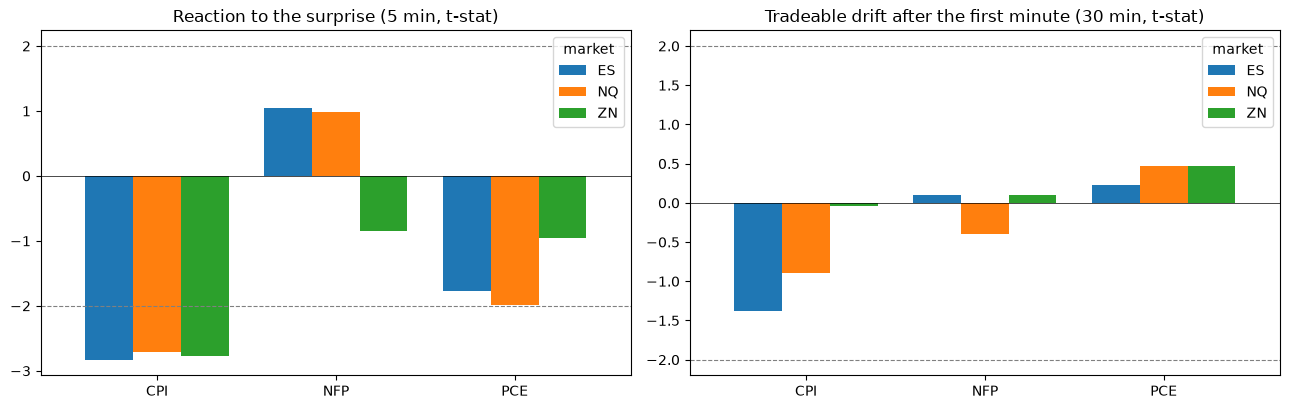

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, title in [(axes[0], "reaction_t_5m", "Reaction to the surprise (5 min, t-stat)"),
                       (axes[1], "drift_t_30m", "Tradeable drift after the first minute (30 min, t-stat)")]:
    summary[col].unstack("market")[list(MARKETS)].plot.bar(ax=ax, width=0.8)
    ax.axhline(2, c="gray", ls="--", lw=0.8); ax.axhline(-2, c="gray", ls="--", lw=0.8); ax.axhline(0, c="k", lw=0.5)
    ax.set_title(title); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb02b_reaction_vs_drift.png", dpi=150); plt.show()

## 8. Interpretation and Conclusion

*Fill this in after running. Suggested structure:*

**1. Does each release move NQ and ZN?** Market impact and reaction R² (Sections 4–5), compared with ES.

**2. Is CPI the dominant release in NQ and ZN too?** Compare CPI's R² and t-stats with NFP and PCE in each market.

**3. Is there a tradeable drift after the first minute?** Section 6 and the stability check. Which market and release combinations pass?

**4. What this means for Notebook 07:** does it justify trading CPI (and the multi-release book) on NQ, and explain why ZN failed?

# 8. Purpose, Research Questions, Answers, and Conclusion

## Purpose of Notebook 02b

Notebooks 01–02 established, **for ES**, that CPI is the only macro release whose surprise strongly and reliably moves the market. Notebooks 05–07 then applied the surprise strategy to **NQ** (Nasdaq-100) and **ZN** (10-year T-note) without repeating that analysis for them. This notebook repeats the **Notebook 02 event study** for NQ and ZN, with ES as the reference, to answer:

> **Is CPI also the valuable release for NQ and ZN?**

**Design:** the same 363 releases (CPI 122, NFP 122, PCE 119; 2016–2026), the same z-scored surprise components and the same multivariate regressions with HC3 standard errors as Notebook 02, for two measures:
- **Reaction** from T−1 (Notebook 02 definition, which includes the first-minute jump);
- **Tradeable drift** from T+1 (Notebook 04 definition, after the first post-release bar).

**Check:** ES reproduces the Notebook 02 returns exactly (maximum difference 3×10⁻¹¹ bps). Coverage: ES 363, NQ 354 and ZN 350 releases with a complete 60-minute window.

---

## Research Questions and Answers

### Section 4: Which release moves each market the most?

| Market | CPI | NFP | PCE | CPI relative | NFP relative | PCE relative |
|---|---|---|---|---|---|---|
| ES | 38.5 bps | 29.6 | 14.9 | **1.39** | 1.07 | 0.54 |
| NQ | 53.6 bps | 36.0 | 18.5 | **1.49** | 1.00 | 0.51 |
| ZN | 22.5 bps | 23.6 | 8.3 | 1.24 | **1.30** | 0.46 |

*(Mean absolute 30-minute reaction; relative = release ÷ the market's average across the three.)*

**Answer:** In **ES and NQ**, CPI causes the largest moves, more so in NQ, which is more rate-sensitive. In **ZN**, the jobs report moves bonds as much as CPI. PCE causes the smallest moves in every market.

### Section 5: Does the surprise explain the reaction?

| R² of the reaction regression (5 min) | ES | NQ | ZN |
|---|---|---|---|
| **CPI** | **0.27** | **0.30** | **0.30** |
| NFP | 0.03 | 0.01 | 0.03 |
| PCE | 0.10 | 0.10 | 0.04 |

| Headline CPI, 5-min reaction | ES | NQ | ZN |
|---|---|---|---|
| Beta (bps per 1-SD hotter surprise) | −20.8 | **−27.7** | −9.9 |
| t-stat | −2.8 | −2.7 | −2.8 |

**Answer:** **Yes. CPI is the dominant release in all three markets.** Its surprise explains about 30% of the reaction everywhere, against 1–3% for NFP and 4–10% for PCE. The directions are economically correct: a hotter CPI print lowers ES, lowers NQ even more, and lowers bond prices (yields rise). The jobs report moves ZN strongly, but the headline surprises barely explain why (R² 0.03), so bonds react to details the headline surprises don't capture.

### Section 6: Is there a tradeable drift after the first minute?

| Headline CPI drift, T+1 → T+30 (multivariate) | ES | NQ | ZN |
|---|---|---|---|
| Beta (bps per 1-SD surprise) | −5.7 | −4.6 | **−0.1** |
| t-stat | −1.37 | −0.90 | **−0.04** |
| Same sign in 2016–20 and 2021–26 | Yes | Yes | Yes (≈ 0) |

**Answer:**
- **ZN has no drift at all.** Bonds absorb the CPI surprise within the first minute.
- **ES and NQ keep a drift in the right direction** (about −5 bps per 1-SD surprise, with a stable sign), but it is **not statistically significant** in this linear regression.
- **NFP and PCE show no drift in any market** (all |t| < 0.5).

### Section 7: Which release is valuable for trading?

By the strict rule of this notebook (drift |t| > 2 **and** a stable sign), **no release passes in any market, including ES.** This does **not** contradict the profitable CPI trades of Notebooks 04–07 (ES random-sign p ≈ 0.006; NQ p ≈ 0.05), because the tests differ:

| | Linear drift regression (this notebook) | Trading tests (Notebooks 04–07) |
|---|---|---|
| Measures | **Size**: bps per unit of surprise | **Direction**: profit from trading the sign |
| Sample | 2016–2026 | Walk-forward 2019–2026 |
| CPI variables | Headline and core together (highly correlated, so they split the effect) | One signal |
| Sensitivity | Dominated by a few very large moves | Each trade counts equally |

With headline and core averaged into one surprise and a longer sample (2010–2026, 147 releases), Jack Duncan's version of this regression finds t = −2.78 for ES. The ES drift is therefore **real but modest**. It is clear in direction-based tests and with more data, and weak in a 122-release linear regression.

---

## Conclusion

| Question | ES | NQ | YM | ZN |
|---|---|---|---|---|
| Is CPI the dominant reaction? | ✅ Yes | ✅ Yes (strongest, beta −27.7) | ✅ Yes (beta −19.2, about 92% of ES) | ✅ Yes; NFP equally large in impact |
| Is there a tradeable CPI drift? | Modest (right sign, stable; significant in trading tests) | Weaker (right sign, stable; borderline in trading) | Modest, like ES (−5.3 bps per SD, t = −1.37; same sign in 2016–20 and 2021–26) | ❌ None (beta ≈ 0) |
| Is NFP or PCE tradeable? | No | No | No (NFP explains more of YM's move, R² 0.07–0.14, but no component is significant) | No |

1. **CPI is the valuable release in all four markets.** Its surprise explains about 27–30% of the five-minute reaction in ES, NQ, YM and ZN, far more than NFP or PCE. This justifies carrying the CPI signal from ES to NQ, YM and ZN in Notebook 07.

2. **Most of the CPI information is priced within the first minute, in every market.** The tradeable drift (about −5 bps per SD in ES, NQ and YM) is small compared with the reaction (−21 bps for ES, −28 for NQ, −19 for YM).

3. **Only the equity indices (ES, NQ and YM) keep part of the information after the first minute.** In ZN it is fully priced within a minute, which explains why the ZN strategies failed in Notebook 07 even before costs.

4. **YM behaves like a slightly smaller ES.** It reacts to the same releases with the same signs, about 90% of ES's CPI response, and the same share of the move explained by the surprise. Its drift after the first minute is almost identical to ES's (−5.3 against −5.7 bps per SD). The one difference is NFP: payrolls explain more of YM's move than of ES's or NQ's, consistent with the Dow's tilt to industrials and banks, but no single NFP component is significant.

5. **The drift is a modest effect.** It is visible in direction-based trading tests and in longer samples, but not strong enough to pass a strict linear-regression test on 2016–2026 alone. The presentation should describe the tradeable edge as real but modest, and concentrated in CPI on the equity indices.

**Overall:** CPI is the market-moving release for stocks and bonds alike, but only the equity indices (ES, NQ and YM) keep a small, tradeable part of the CPI surprise after the first minute. Bonds (ZN) price it instantly. This is consistent with Notebook 07: the surprise strategy works on ES, NQ and YM and fails on ZN. Adding YM raises the equity portfolio from 0.72 (ES + NQ) to 0.78 (ES + NQ + YM).

> **Overall:** CPI is the market-moving release for stocks and bonds alike, but only the equity markets (ES and NQ) keep a small, tradeable part of the CPI surprise after the first minute. Bonds (ZN) price it instantly. This is consistent with Notebook 07: the surprise strategy works on ES and NQ and fails on ZN.